# Step 5 — Explicit Method

The explicit scheme computes each new time step as a direct weighted average of the previous values — no linear system to solve.

$$V^{n+1}_i = \alpha_i V^n_{i-1} + \beta_i V^n_i + \gamma_i V^n_{i+1}$$

The trade-off: it is only **conditionally stable**. If the time step $dt$ is too large, errors explode.
Stability requires $\beta_i \geq 0$ for all $i$, which gives:
$$dt \leq \frac{1}{\sigma^2 (M-1)^2 + r}$$

In [3]:
import sys
sys.path.insert(0, '..')

import warnings
import numpy as np
import matplotlib.pyplot as plt

from src.solvers.explicit import solve_explicit, stability_limit
from src.solvers.implicit import solve_implicit
from src.solvers.crank_nicolson import solve_crank_nicolson
from src.core import bs_price

## Parameters

In [4]:
K     = 100
r     = 0.05
sigma = 0.20
T     = 1.0
S_max = 3 * K
S0    = 100.0

M = 100
N_min = stability_limit(T, r, sigma, M)
print(f'Minimum N for stability with M={M}: {N_min}')

Minimum N for stability with M=100: 393


## 1. Instability Demo — dt Too Large

Using far fewer time steps than the stability limit causes the solution to blow up.

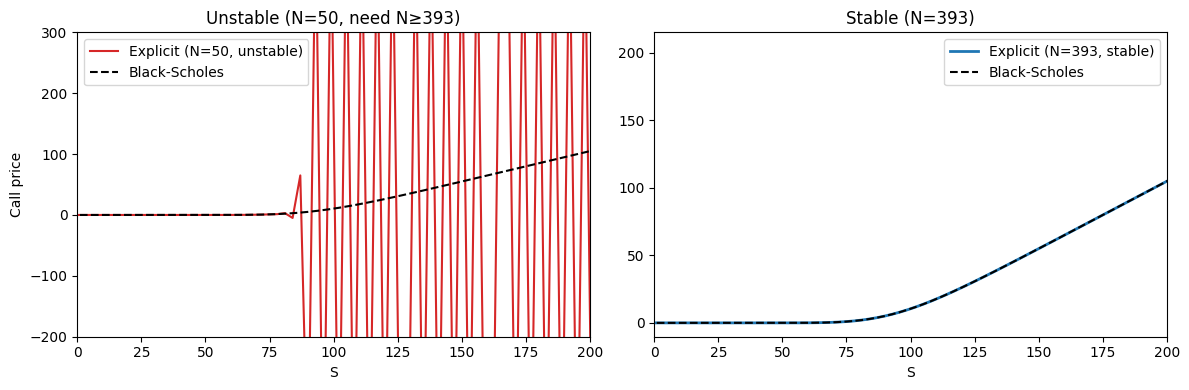

In [5]:
S_plot = np.linspace(1, S_max, 300)
bs = np.array([bs_price(s, K, T, r, sigma, option_type="call") for s in S_plot])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Unstable: N << N_min
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    S_bad, V_bad = solve_explicit(S_max, K, r, sigma, T, M, N=50, option_type='call')

axes[0].plot(S_bad, np.clip(V_bad, -500, 500), lw=1.5, color='tab:red', label='Explicit (N=50, unstable)')
axes[0].plot(S_plot, bs, 'k--', lw=1.5, label='Black-Scholes')
axes[0].set_xlim(0, 200)
axes[0].set_ylim(-200, 300)
axes[0].set_xlabel('S')
axes[0].set_ylabel('Call price')
axes[0].set_title(f'Unstable (N=50, need N≥{N_min})')
axes[0].legend()

# Stable: N >= N_min
S_ok, V_ok = solve_explicit(S_max, K, r, sigma, T, M, N=N_min, option_type='call')
axes[1].plot(S_ok, V_ok, lw=2, label=f'Explicit (N={N_min}, stable)')
axes[1].plot(S_plot, bs, 'k--', lw=1.5, label='Black-Scholes')
axes[1].set_xlim(0, 200)
axes[1].set_xlabel('S')
axes[1].set_title(f'Stable (N={N_min})')
axes[1].legend()

plt.tight_layout()
plt.show()

## 2. Accuracy Comparison — All Three Methods

For a fair comparison we give each method the same number of stock grid points (M=100) and use the minimum stable N for explicit. Implicit and CN are unconditionally stable so they can use any N.

In [6]:
exact = bs_call_price(S0, K, r, sigma, T)

Se, Ve = solve_explicit(S_max, K, r, sigma, T, M=M, N=N_min, option_type='call')
Si, Vi = solve_implicit(S_max, K, r, sigma, T, M=M, N=N_min, option_type='call')
Sc, Vc = solve_crank_nicolson(S_max, K, r, sigma, T, M=M, N=N_min, option_type='call')

for label, S_, V_ in [('Explicit', Se, Ve), ('Implicit', Si, Vi), ('Crank-Nicolson', Sc, Vc)]:
    err = abs(np.interp(S0, S_, V_) - exact)
    print(f'{label:16s}  price={np.interp(S0, S_, V_):.4f}  error={err:.6f}')
print(f'{"Black-Scholes":16s}  price={exact:.4f}')

Explicit          price=10.4684  error=0.017779
Implicit          price=10.4631  error=0.012474
Crank-Nicolson    price=10.4657  error=0.015127
Black-Scholes     price=10.4506


## 3. Convergence vs Grid Size

For each M, explicit must use at least N_min steps. Implicit and CN use the same N for a fair comparison.

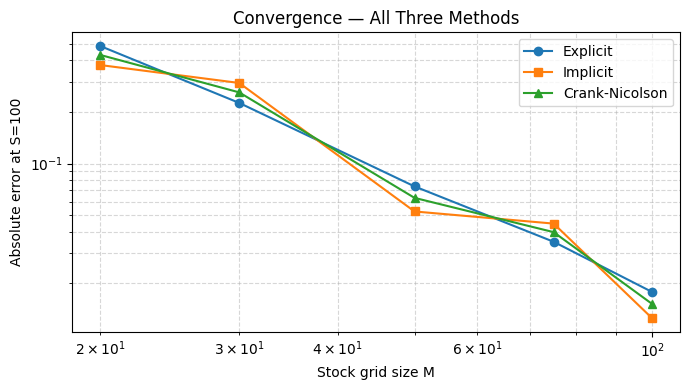

In [8]:
grid_sizes = [20, 30, 50, 75, 100]
err_exp, err_imp, err_cn = [], [], []

for m in grid_sizes:
    n = stability_limit(T, r, sigma, m)
    Se, Ve = solve_explicit(S_max, K, r, sigma, T, M=m, N=n, option_type='call')
    Si, Vi = solve_implicit(S_max, K, r, sigma, T, M=m, N=n, option_type='call')
    Sc, Vc = solve_crank_nicolson(S_max, K, r, sigma, T, M=m, N=n, option_type='call')
    err_exp.append(abs(np.interp(S0, Se, Ve) - exact))
    err_imp.append(abs(np.interp(S0, Si, Vi) - exact))
    err_cn.append(abs(np.interp(S0, Sc, Vc) - exact))

plt.figure(figsize=(7, 4))
plt.loglog(grid_sizes, err_exp, 'o-', label='Explicit')
plt.loglog(grid_sizes, err_imp, 's-', label='Implicit')
plt.loglog(grid_sizes, err_cn,  '^-', label='Crank-Nicolson')
plt.xlabel('Stock grid size M')
plt.ylabel('Absolute error at S=100')
plt.title('Convergence — All Three Methods')
plt.legend()
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.tight_layout()
plt.show()